<div style='background:#8B0000; padding:20px; border-radius:8px; margin-bottom:10px'>
<h1 style='color:white; text-align:center; margin:0'>Reconocimiento de Patrones</h1>
<h2 style='color:#ffcccc; text-align:center; margin:5px 0 0 0'>Challenge 7 — Redes Neuronales Convolucionales para Imágenes Biomédicas</h2>
<p style='color:#ffaaaa; text-align:center; margin:5px 0 0 0'>Ingeniería Biomédica · UPCH · 2026-1</p>
</div>

> **Nota para estudiantes:** las celdas con `TODO` indican exactamente qué deben completar. Las pistas orientan el razonamiento, pero no reemplazan la interpretación clínica.


## Contexto clínico

En el Challenge 6 entrenaste un **perceptrón** y un **MLP** usando variables tabulares del dataset Breast Cancer Wisconsin. Ahora pasamos de datos tabulares a **imágenes biomédicas**.

Trabajaremos con **PneumoniaMNIST**, un dataset de imágenes de radiografía de tórax en escala de grises, reducido a 28×28 píxeles, con dos clases:

- `0 = Normal`
- `1 = Pneumonia`

El objetivo será entrenar modelos en **PyTorch** para distinguir entre radiografías normales y radiografías con neumonía. Primero construiremos un **baseline MLP** que aplana la imagen y luego una **CNN** que conserva la estructura espacial.

**Pregunta clínica:** ¿por qué una CNN debería ser más adecuada que un MLP cuando la entrada es una imagen? ¿Qué error clínico es más crítico: clasificar una neumonía como normal o clasificar un caso normal como neumonía?

---
> **Dataset:** PneumoniaMNIST, colección MedMNIST.  
> Se descarga directamente desde Python usando la librería `medmnist`.


<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
🧑‍🎓 <b>VERSIÓN ESTUDIANTE</b> — completa los espacios en blanco, ejecuta el notebook en orden y responde las preguntas de interpretación clínica.
</div>


---
## Ejercicio 1 — Diseño previo al código

### 1.1 — De MLP a CNN

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — responde antes de programar
</div>

**📝 Tu respuesta (edita esta celda):**

> **TODO:** responde con 2–3 líneas por pregunta. Usa conceptos de CNN, MLP y métricas clínicas.

**1. ¿Qué problema tiene usar un MLP directamente sobre una imagen?**

El problema principal al usar los MLP consiste en que estos aplanan la imagen a analizar, de esta manera dejan fuera del análisis ciertas características que solo son perceptibles cuando se hace un examen espacial. Además se aumenta el costo computacional.  
___

---

**2. ¿Qué ventaja tiene una CNN?**

Las CNN tienen como ventaja la convolución. Las entradas de esta red pueden ser complejas y se procesan de forma local usando filtros que comparten pesos. Esto resulta en una capacidad de análisis más profunda que permite extraer patrones en cualquier ubicación de la imagen.
___

---

**3. ¿Qué podría representar un filtro convolucional en una radiografía de tórax?**

Pueden representar la identificación de patrones que solo se mantienen al hacer un examen espacial. Por ejemplo en las primeras capas, se pueden identificar variaciones en el área y bordes mientras que en las más profundas se encontrarían patrones específicos, esto se asemejaría más al trabajo de un especialista.
___


### 1.2 — Convolución, pooling y clasificación

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — responde con tus palabras
</div>

**📝 Tu respuesta (edita esta celda):**

> **TODO:** responde con 2–3 líneas por pregunta. Usa conceptos de CNN, MLP y métricas clínicas.

**1. ¿Qué produce una capa convolucional?**

Una capa convolucional extrae características relevantes de la imagen mediante filtros. El resultado son mapas de características que resaltan patrones como bordes, texturas o formas útiles para la clasificación.
___

**2. ¿Para qué sirve MaxPooling?** 

MaxPooling reduce el tamaño de los mapas de características pero conserva la información más importante. Esto disminuye el costo computacional y ayuda a que la red sea más robusta a pequeñas variaciones en la imagen.
___

**3. ¿Por qué al final usamos una capa lineal?**

La capa lineal toma las características aprendidas por la CNN y las combina para generar una predicción final. En este caso produce un valor que representa la probabilidad de la presencia de la enfermedad.
___

**4. ¿Por qué seguimos usando `BCEWithLogitsLoss`?**

Porque el problema sigue siendo de clasificación binaria (enfermedad presente o ausente). Esta función combina la activación sigmoide y la entropía cruzada binaria de forma numéricamente estable, lo que mejora el entrenamiento del modelo.
___


### 1.3 — Pipeline completo

**TODO:** completa cada paso del pipeline con una frase breve.

Completa el siguiente pipeline:

```text
PneumoniaMNIST
      │
      ▼
[ Paso A ] Cargar y dividir el dataset en entrenamiento, validación y prueba.
      │
      ▼
[ Paso B ] Aplicar transformaciones y normalización.
      │
      ▼
[ Paso C ] Crear DataLoaders para formar minibatches.
      │
      ▼
[ Paso D ] Pasar las imágenes por las capas convolucionales.
      │
      ▼
[ Paso E ] Aplicar pooling y obtener características compactas.
      │
      ▼
[ Paso F ] Usar una capa lineal para generar los logits de salida.
      │
      ▼
[ Paso G ] Entrenar el modelo con BCEWithLogitsLoss y optimización por gradiente.
      │
      ▼
[ Paso H ] Evaluar el modelo con métricas como accuracy, sensibilidad y AUC.
```

**📝 Pregunta:** ¿por qué conviene entrenar primero un MLP baseline antes de entrenar la CNN?

Porque el MLP es un modelo más simple que permite comparar resultados. Así podemos verificar que el pipeline funciona correctamente y determinar si la CNN realmente aporta una mejoras.
___


---
## Ejercicio 2 — Setup y carga de datos

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>

### Paso 2.1 — Librerías

In [ ]:
# ── Instalación robusta de MedMNIST ─────────────────────────────
# En Google Colab debería ejecutarse sin problemas.
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("medmnist") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "medmnist"])

# ── Colores institucionales UPCH ───────────────────────────────
UPCH_RED    = '#8B0000'
UPCH_BLUE   = '#1565C0'
UPCH_GREEN  = '#2E7D32'
UPCH_ORANGE = '#E65100'
UPCH_PURPLE = '#6A1B9A'
UPCH_GRAY   = '#4A4A4A'

# ── Librerías base ──────────────────────────────────────────────
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── PyTorch ─────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms

# ── Dataset MedMNIST ────────────────────────────────────────────
from medmnist import PneumoniaMNIST, INFO

# ── Métricas ────────────────────────────────────────────────────
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve
)

sns.set_context("notebook")
plt.rcParams['figure.figsize'] = (7, 4)

def seed_everything(seed=42):
    """Fija semillas para reproducibilidad."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


### Paso 2.2 — Transformaciones y carga de PneumoniaMNIST

In [ ]:
# ── Información del dataset ─────────────────────────────────────
info = INFO['pneumoniamnist']
print("Descripción:", info['description'][:300], "...")
print("Clases:", info['label'])
print("Canales:", info['n_channels'])

# ── Transformación: PIL/NumPy → Tensor normalizado ──────────────
# TODO 1: completa mean y std para una imagen en escala de grises.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

# ── Carga de splits oficiales ───────────────────────────────────
train_dataset = PneumoniaMNIST(split='train', transform=transform, download=True)
val_dataset   = PneumoniaMNIST(split='val',   transform=transform, download=True)
test_dataset  = PneumoniaMNIST(split='test',  transform=transform, download=True)

print(f"Train: {len(train_dataset)} imágenes")
print(f"Val:   {len(val_dataset)} imágenes")
print(f"Test:  {len(test_dataset)} imágenes")

sample_img, sample_label = train_dataset[0]
print("Forma de una imagen:", sample_img.shape)
print("Etiqueta ejemplo:", int(sample_label[0]))


Descripción: The PneumoniaMNIST is based on a prior dataset of 5,856 pediatric chest X-Ray images. The task is binary-class classification of pneumonia against normal. We split the source training set with a ratio of 9:1 into training and validation set and use its source validation set as the test set. The sour ...
Clases: {'0': 'normal', '1': 'pneumonia'}
Canales: 1


100%|██████████| 4.17M/4.17M [00:01<00:00, 2.53MB/s]


Train: 4708 imágenes
Val:   524 imágenes
Test:  624 imágenes
Forma de una imagen: torch.Size([1, 28, 28])
Etiqueta ejemplo: 1


### Paso 2.3 — Distribución de clases y visualización inicial

class_name,Normal,Pneumonia
split,,
test,234,390
train,1214,3494
val,135,389


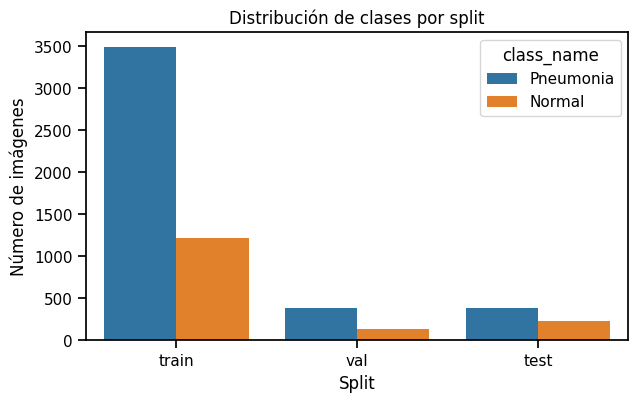

In [ ]:
# ── Distribución de clases ──────────────────────────────────────
label_map = {0: "Normal", 1: "Pneumonia"}

def get_label_array(dataset):
    return dataset.labels.reshape(-1).astype(int)

train_labels = get_label_array(train_dataset)
val_labels   = get_label_array(val_dataset)
test_labels  = get_label_array(test_dataset)

dist_df = pd.DataFrame({
    "split": ["train"] * len(train_labels) + ["val"] * len(val_labels) + ["test"] * len(test_labels),
    "label": np.concatenate([train_labels, val_labels, test_labels])
})
dist_df["class_name"] = dist_df["label"].map(label_map)

display(pd.crosstab(dist_df["split"], dist_df["class_name"]))

fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=dist_df, x="split", hue="class_name", ax=ax)
ax.set_title("Distribución de clases por split")
ax.set_xlabel("Split")
ax.set_ylabel("Número de imágenes")
plt.show()

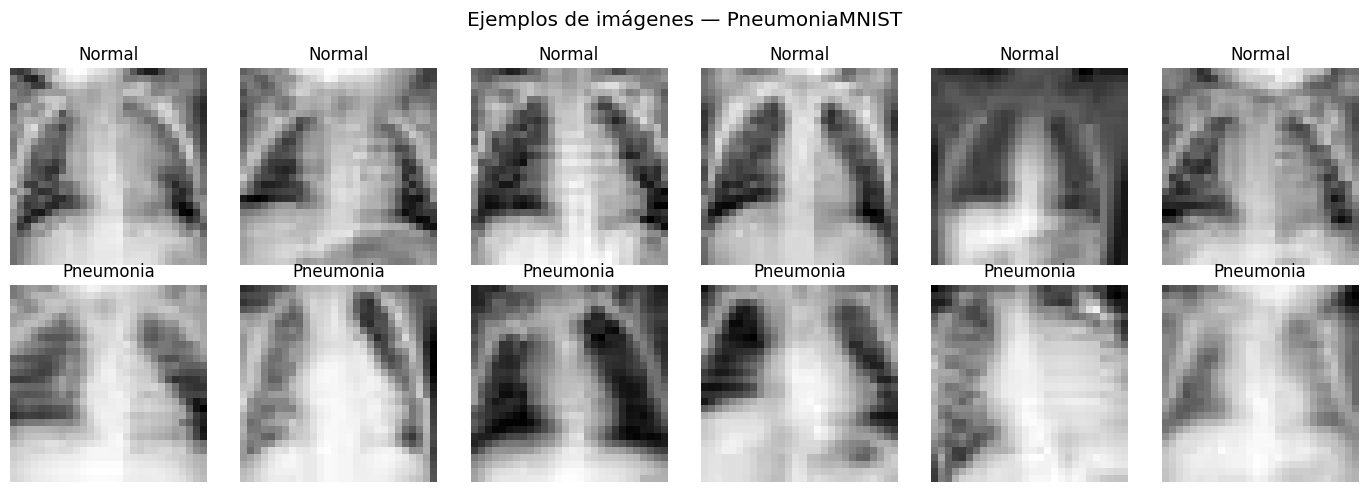

In [ ]:
# ── Visualización de ejemplos ───────────────────────────────────
def unnormalize_img(img_tensor):
    """Convierte tensor normalizado [-1,1] a imagen [0,1] para visualizar."""
    return (img_tensor.squeeze().cpu().numpy() * 0.5) + 0.5

def plot_class_examples(dataset, n_per_class=6):
    labels = get_label_array(dataset)
    fig, axes = plt.subplots(2, n_per_class, figsize=(14, 5))

    for class_id in [0, 1]:
        idxs = np.where(labels == class_id)[0]
        chosen = np.random.choice(idxs, size=n_per_class, replace=False)

        for j, idx in enumerate(chosen):
            img, label = dataset[idx]
            axes[class_id, j].imshow(unnormalize_img(img), cmap="gray")
            axes[class_id, j].axis("off")
            axes[class_id, j].set_title(label_map[int(label[0])])

    plt.suptitle("Ejemplos de imágenes — PneumoniaMNIST")
    plt.tight_layout()
    plt.show()

plot_class_examples(train_dataset, n_per_class=6)

### Paso 2.4 — Interpretación inicial

**📝 Tu respuesta (edita esta celda):**

> **TODO:** responde con 2–3 líneas por pregunta. Usa conceptos de CNN, MLP y métricas clínicas.

**1. ¿Qué forma tiene cada imagen y qué significa cada dimensión?**  
Las imagenes tienen forma 1×28×28. Ese 1 implica usar escala de grises, mientras que 28×28 representa la altura y el ancho.

**2. ¿Observas desbalance de clases? ¿Por qué importa?**  
Si una clase aparece con mucha mayor frecuencia que la otra, existe desbalance. Esto importa sesgarse favorecer la clase mayoritaria y métricas engañosas.

**3. En este problema, ¿qué sería un falso negativo?**  
Un falso negativo sería clasificar un caso de neumonía como normal. Es crucial evitar este error porque podría retrasar el diagnóstico y tratamiento.

**4. ¿Por qué una CNN puede ser apropiada para este tipo de dato?**  
Las CNN aprovechan la estructura espacial de las imágenes. Pueden detectar patrones locales preservando la relación entre píxeles vecinos.


---
# PARTE 1 — DataLoader y mini-batches de imágenes
## Ejercicio 3 — Preparación de mini-batches

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>

### Paso 3.1 — Creación de DataLoaders

In [ ]:
# ── DataLoaders ─────────────────────────────────────────────────
# TODO 2: define un tamaño de mini-batch y el orden de mezcla.
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

xb, yb = next(iter(train_loader))

print("Mini-batch de imágenes:", xb.shape)
print("Mini-batch de etiquetas:", yb.shape)
print("Tipo de dato X:", xb.dtype)
print("Tipo de dato y:", yb.dtype)


Mini-batch de imágenes: torch.Size([64, 1, 28, 28])
Mini-batch de etiquetas: torch.Size([64, 1])
Tipo de dato X: torch.float32
Tipo de dato y: torch.int64


### Paso 3.2 — ¿Qué significa la forma del tensor?

In [ ]:
# ── Interpretación de dimensiones ───────────────────────────────
# TODO 3: completa los prints usando las variables B, C, H y W.
B, C, H, W = xb.shape
print(f"B = {B} imágenes por mini-batch")
print(f"C = {C} canal(es) de imagen")
print(f"H = {H} píxeles de alto")
print(f"W = {W} píxeles de ancho")


B = 64 imágenes por mini-batch
C = 1 canal(es) de imagen
H = 28 píxeles de alto
W = 28 píxeles de ancho


### Paso 3.3 — Interpretación

**📝 Tu respuesta (edita esta celda):**

> **TODO:** responde con 2–3 líneas por pregunta. Usa conceptos de CNN, MLP y métricas clínicas.

**1. ¿Qué significa el formato `[batch, channels, height, width]`?**  
Representa un conjunto de imágenes procesadas simultáneamente. Batch es el número de imágenes, channels el número de canales y height y width corresponden a las dimensiones espaciales.

**2. ¿Por qué PneumoniaMNIST tiene un solo canal?**  
Porque las radiografías están en escala de grises. Esto implica que un único canal es suficiente para representar la intensidad de cada píxel.

**3. ¿Por qué entrenamos con mini-batches en lugar de procesar todo el dataset de una sola vez?**  
Los mini-batches usan menos memoria y aceleran el entrenamiento. Además, introducen variabilidad en las actualizaciones del modelo, lo que puede favorecer la generalización.


---
# PARTE 2 — Baseline MLP con imagen aplanada
## Ejercicio 4 — Modelo MLP para comparar contra CNN

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa esto durante la sesión
</div>

### Paso 4.1 — Definición del baseline MLP

In [ ]:
# ── Baseline: MLP que aplana la imagen ──────────────────────────
# TODO 4: completa las dimensiones del MLP.
class FlattenMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28*1, 128),  # TODO 4.1: capa de entrada → capa oculta
            nn.ReLU(),
            nn.Linear(128, 1)   # TODO 4.2: capa oculta → 1 logit
        )

    def forward(self, x):
        return self.net(x)

mlp_model = FlattenMLP().to(device)
print(mlp_model)


FlattenMLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)


### Paso 4.2 — Funciones generales de entrenamiento y evaluación

<div style='background:#e8f5e9; padding:8px 14px; border-left:4px solid #2e7d32; border-radius:4px; margin:8px 0'>
⏱️ <b>EN CLASE</b> — completa el cálculo de desbalance y el ciclo de entrenamiento
</div>

**Nota:** `pos_weight` ayuda a manejar desbalance en la función de pérdida, pero la decisión clínica final se analiza con sensibilidad, especificidad y umbrales.


In [ ]:
# ── Conteo de parámetros ────────────────────────────────────────
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Parámetros del MLP:", count_parameters(mlp_model))

# ── Peso para clase positiva por desbalance ─────────────────────
# TODO 5: cuenta positivos y negativos usando train_labels.
# En este dataset: 0 = Normal, 1 = Pneumonia.
n_pos = (train_labels == 1).sum()
n_neg = (train_labels == 0).sum()
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)

print(f"n_neg={n_neg}, n_pos={n_pos}, pos_weight={pos_weight.item():.3f}")

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

def train_one_epoch(model, loader, loss_fn, optimizer, device):
    model.train()

    total_loss = 0.0
    correct = 0
    n = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.float().view(-1, 1).to(device)

        # TODO 6: forward pass → pérdida → backpropagation → actualización
        logits = model(X_batch)
        loss = loss_fn(logits, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()
        correct += (preds == y_batch).sum().item()
        n += X_batch.size(0)

    return total_loss / n, correct / n


@torch.no_grad()
def evaluate_one_epoch(model, loader, loss_fn, device):
    model.eval()

    total_loss = 0.0
    correct = 0
    n = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.float().view(-1, 1).to(device)

        logits = model(X_batch)
        loss = loss_fn(logits, y_batch)

        total_loss += loss.item() * X_batch.size(0)

        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()
        correct += (preds == y_batch).sum().item()
        n += X_batch.size(0)

    return total_loss / n, correct / n


def fit_model(model, train_loader, val_loader, loss_fn, optimizer, device, epochs=6):
    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [],  "val_acc": []
    }

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
        val_loss, val_acc     = evaluate_one_epoch(model, val_loader, loss_fn, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
            f"train_acc={train_acc:.3f} | val_acc={val_acc:.3f}"
        )

    return history


def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["train_loss"], marker="o", label="train")
    axes[0].plot(history["val_loss"], marker="o", label="val")
    axes[0].set_title(f"{title} — Loss")
    axes[0].set_xlabel("Época")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(history["train_acc"], marker="o", label="train")
    axes[1].plot(history["val_acc"], marker="o", label="val")
    axes[1].set_title(f"{title} — Accuracy")
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


Parámetros del MLP: 100609
n_neg=1214, n_pos=3494, pos_weight=0.347


### Paso 4.3 — Entrenamiento del MLP

Epoch 01/20 | train_loss=0.1292 | val_loss=0.0912 | train_acc=0.898 | val_acc=0.903
Epoch 02/20 | train_loss=0.0770 | val_loss=0.0752 | train_acc=0.940 | val_acc=0.943
Epoch 03/20 | train_loss=0.0720 | val_loss=0.0793 | train_acc=0.946 | val_acc=0.918
Epoch 04/20 | train_loss=0.0643 | val_loss=0.0727 | train_acc=0.953 | val_acc=0.948
Epoch 05/20 | train_loss=0.0595 | val_loss=0.0787 | train_acc=0.955 | val_acc=0.920
Epoch 06/20 | train_loss=0.0609 | val_loss=0.0694 | train_acc=0.955 | val_acc=0.947
Epoch 07/20 | train_loss=0.0566 | val_loss=0.0666 | train_acc=0.956 | val_acc=0.935
Epoch 08/20 | train_loss=0.0524 | val_loss=0.0684 | train_acc=0.960 | val_acc=0.948
Epoch 09/20 | train_loss=0.0505 | val_loss=0.0628 | train_acc=0.962 | val_acc=0.945
Epoch 10/20 | train_loss=0.0485 | val_loss=0.0640 | train_acc=0.964 | val_acc=0.943
Epoch 11/20 | train_loss=0.0468 | val_loss=0.0613 | train_acc=0.965 | val_acc=0.947
Epoch 12/20 | train_loss=0.0429 | val_loss=0.0639 | train_acc=0.968 | val_ac

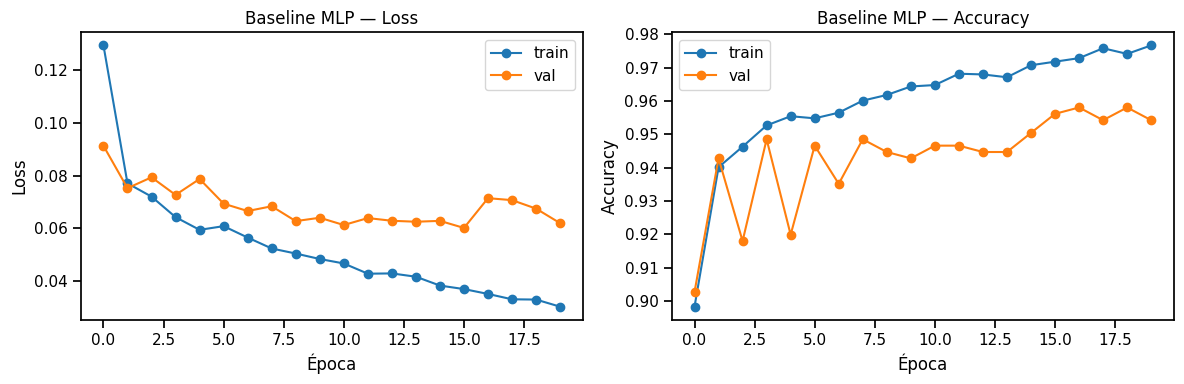

In [ ]:
# ── Entrenamiento del baseline MLP ──────────────────────────────
# TODO 7: define learning rate y número de épocas.
#         Pista: empieza con lr=1e-3 y pocas épocas para que sea rápido en clase.
seed_everything(42)

mlp_model = FlattenMLP().to(device)
mlp_optimizer = optim.Adam(mlp_model.parameters(), lr=1e-3)

mlp_history = fit_model(
    model=mlp_model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=mlp_optimizer,
    device=device,
    epochs=20
)

plot_history(mlp_history, "Baseline MLP")


### Paso 4.4 — Interpretación del baseline

**📝 Tu respuesta (edita esta celda):**

> **TODO:** responde con 2–3 líneas por pregunta. Usa conceptos de CNN, MLP y métricas clínicas.

**1. ¿Qué información espacial pierde el MLP al aplanar la imagen?**  
Al convertir la imagen en un vector, se pierde la correlación espacial entre píxeles vecinos. El modelo ya no sabe qué regiones están cerca ni puede identificar patrones locales de forma natural.

**2. ¿Por qué este MLP sirve como baseline y no necesariamente como mejor modelo final?**  
Porque es una arquitectura simple que permite establecer un punto de comparación. Sin embargo, no está diseñada específicamente para ser usada en imágenes, por lo que una CNN suele aprovechar mejor la información visual disponible.


---
# PARTE 3 — CNN para clasificación de radiografías
## Ejercicio 5 — Modelo convolucional en PyTorch

<div style='background:#fff3e0; padding:8px 14px; border-left:4px solid #e65100; border-radius:4px; margin:8px 0'>
📚 <b>TAREA</b> — completa esto antes de la siguiente clase
</div>

### Paso 5.1 — Definición de la CNN

In [ ]:
# ── CNN simple para imágenes 28×28 en escala de grises ──────────
# TODO 8: completa la arquitectura CNN.
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),  # TODO 8.3  # TODO 8.1
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),  # TODO 8.4,  # TODO 8.2

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),  # TODO 8.5: flatten features → capa oculta
            nn.ReLU(),
            nn.Linear(128, 1)  # TODO 8.6: capa oculta → 1 logit
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

cnn_model = SimpleCNN().to(device)
print(cnn_model)
print("Parámetros de la CNN:", count_parameters(cnn_model))


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)
Parámetros de la CNN: 205761


### Paso 5.2 — Verificación de dimensiones con un mini-batch

In [ ]:
# ── Sanity check de dimensiones ─────────────────────────────────
# TODO 9: pasa el mismo mini-batch por extractor de características y modelo completo.
xb, yb = next(iter(train_loader))
xb = xb.to(device)

with torch.no_grad():
    feature_maps = cnn_model.features(xb)
    logits = cnn_model(xb)

print("Entrada:", xb.shape)
print("Después de convoluciones + pooling:", feature_maps.shape)
print("Salida logits:", logits.shape)


Entrada: torch.Size([64, 1, 28, 28])
Después de convoluciones + pooling: torch.Size([64, 32, 7, 7])
Salida logits: torch.Size([64, 1])


### Paso 5.3 — Entrenamiento de la CNN

Epoch 01/20 | train_loss=0.1532 | val_loss=0.0822 | train_acc=0.861 | val_acc=0.947
Epoch 02/20 | train_loss=0.0812 | val_loss=0.0855 | train_acc=0.937 | val_acc=0.901
Epoch 03/20 | train_loss=0.0707 | val_loss=0.0674 | train_acc=0.946 | val_acc=0.945
Epoch 04/20 | train_loss=0.0669 | val_loss=0.0766 | train_acc=0.948 | val_acc=0.920
Epoch 05/20 | train_loss=0.0578 | val_loss=0.0577 | train_acc=0.956 | val_acc=0.962
Epoch 06/20 | train_loss=0.0505 | val_loss=0.0698 | train_acc=0.961 | val_acc=0.958
Epoch 07/20 | train_loss=0.0487 | val_loss=0.0651 | train_acc=0.963 | val_acc=0.958
Epoch 08/20 | train_loss=0.0495 | val_loss=0.0562 | train_acc=0.962 | val_acc=0.958
Epoch 09/20 | train_loss=0.0407 | val_loss=0.0568 | train_acc=0.970 | val_acc=0.966
Epoch 10/20 | train_loss=0.0398 | val_loss=0.0522 | train_acc=0.970 | val_acc=0.956
Epoch 11/20 | train_loss=0.0350 | val_loss=0.0528 | train_acc=0.974 | val_acc=0.964
Epoch 12/20 | train_loss=0.0327 | val_loss=0.0535 | train_acc=0.977 | val_ac

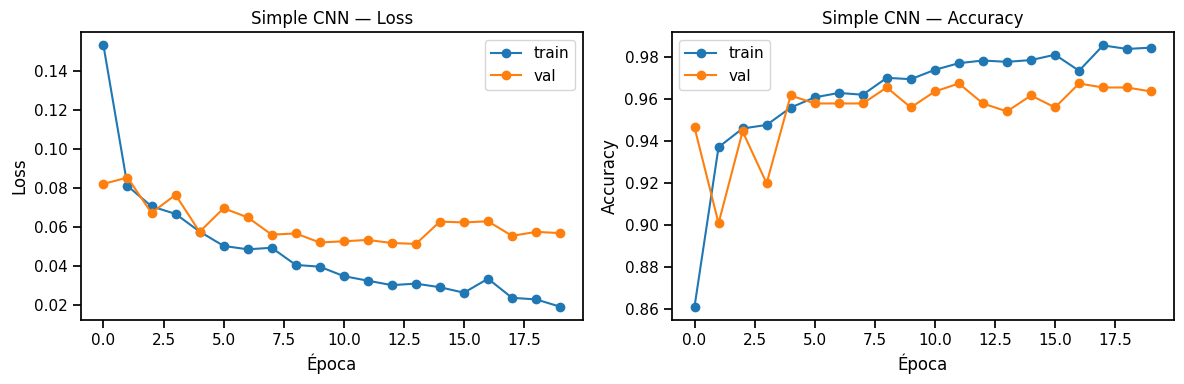

In [ ]:
# ── Entrenamiento de la CNN ─────────────────────────────────────
# TODO 10: define learning rate y épocas para la CNN.
seed_everything(42)

cnn_model = SimpleCNN().to(device)
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=1e-3)

cnn_history = fit_model(
    model=cnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=cnn_optimizer,
    device=device,
    epochs=20
)

plot_history(cnn_history, "Simple CNN")


### Paso 5.4 — Comparación visual de curvas

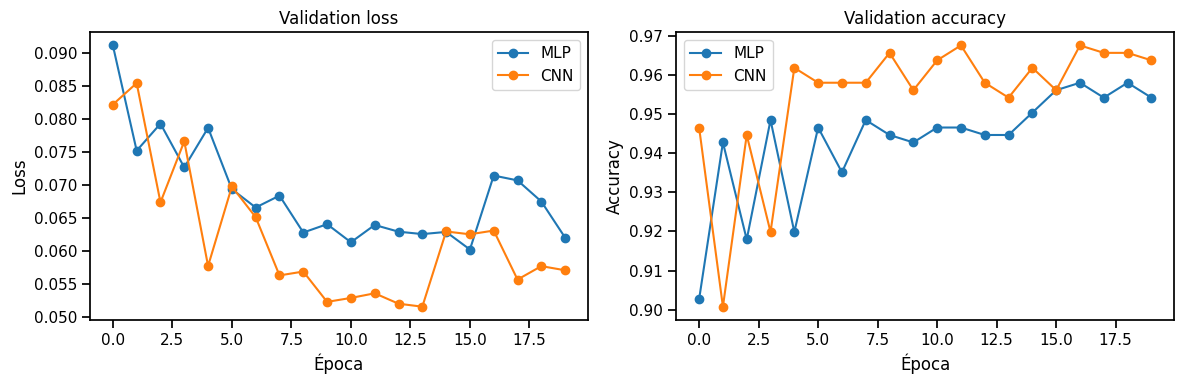

In [ ]:
# ── Comparación de curvas MLP vs CNN ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(mlp_history["val_loss"], marker="o", label="MLP")
axes[0].plot(cnn_history["val_loss"], marker="o", label="CNN")
axes[0].set_title("Validation loss")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(mlp_history["val_acc"], marker="o", label="MLP")
axes[1].plot(cnn_history["val_acc"], marker="o", label="CNN")
axes[1].set_title("Validation accuracy")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

### Paso 5.5 — Interpretación CNN vs MLP

**📝 Tu respuesta (edita esta celda):**

> **TODO:** responde con 2–3 líneas por pregunta. Usa conceptos de CNN, MLP y métricas clínicas.

**1. ¿La CNN mejora frente al MLP? Usa tus curvas y métricas, no solo accuracy.**  
Sí, la CNN obtiene mejores gráficas de pérdida y accuracy. Se muestra una mejora real sobre el MLP. Es importante evaluar varias métricas porque la accuracy por sí sola puede ocultar errores clínicamente relevantes. Se ve en una tabla más adelante que el F1, especificidad y ROC-AUC mejoran con este modelo.

**2. ¿Qué aporta la convolución que no aporta el MLP al aplanar la imagen?**  
La convolución es capaz de detectar patrones locales utilizando filtros. Esto permite reconocer estructuras visuales importantes manteniendo la información espacial.

**3. Si la CNN tiene mejor AUC o especificidad, pero menor sensibilidad con umbral 0.5, ¿cómo interpretarías ese resultado?**  
Significa que el modelo discrimina bien entre clases y reduce falsos positivos, pero deja escapar algunos casos positivos como es el caso del modelo. Es recomendable como siguiente paso ajustar el umbral para mejorar la sensibilidad.

**4. ¿Qué factores podrían explicar que una CNN simple no mejore mucho frente al baseline?**  
Puede deberse a pocas épocas de entrenamiento, hiperparámetros errados o a que el dataset no sea lo suficientemente grande.


---
# PARTE 4 — Métricas clínicas y análisis de errores
## Ejercicio 6 — Evaluación final

<div style='background:#fff3e0; padding:8px 14px; border-left:4px solid #e65100; border-radius:4px; margin:8px 0'>
📚 <b>TAREA</b> — completa esto antes de la siguiente clase
</div>

### Paso 6.1 — Predicción de probabilidades

In [ ]:
# ── Predicción de probabilidades en test ────────────────────────
# TODO 11: convierte logits en probabilidades con sigmoid.
@torch.no_grad()
def predict_proba(model, loader, device):
    model.eval()

    all_probs = []
    all_true = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        probs = torch.sigmoid(logits)

        all_probs.extend(probs)
        all_true.extend(y_batch.numpy().reshape(-1).astype(int))

    return np.array(all_true), np.array(all_probs)

y_test_true, mlp_prob = predict_proba(mlp_model, test_loader, device)
_, cnn_prob = predict_proba(cnn_model, test_loader, device)

print("Primeras probabilidades MLP:", mlp_prob[:5])
print("Primeras probabilidades CNN:", cnn_prob[:5])


Primeras probabilidades MLP: [[9.9999332e-01]
 [9.9999118e-01]
 [9.8739457e-01]
 [4.3153274e-04]
 [9.9987304e-01]]
Primeras probabilidades CNN: [[9.9999475e-01]
 [9.9985254e-01]
 [9.8540616e-01]
 [1.1068028e-05]
 [9.9998438e-01]]


### Paso 6.2 — Métricas clínicas

In [ ]:
# ── Métricas clínicas ───────────────────────────────────────────
# TODO 12: completa sensibilidad, especificidad y precisión.
def clinical_metrics(y_true, y_prob, threshold=0.5, model_name="model"):
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    precision   = tp / (tp + fp) if (tp + fp) > 0 else np.nan

    return {
        "model": model_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "sensitivity_recall": sensitivity,
        "specificity": specificity,
        "precision": precision,
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "TN": tn, "FP": fp, "FN": fn, "TP": tp
    }

results = pd.DataFrame([
    clinical_metrics(y_test_true, mlp_prob, threshold=0.5, model_name="MLP"),
    clinical_metrics(y_test_true, cnn_prob, threshold=0.5, model_name="CNN")
])

display(results)


,model,threshold,accuracy,sensitivity_recall,specificity,precision,f1,roc_auc,TN,FP,FN,TP
0,MLP,0.5,0.881410,0.979487,0.717949,0.852679,0.911695,0.938346,168,66,8,382
1,CNN,0.5,0.897436,0.976923,0.764957,0.873853,0.922518,0.944839,179,55,9,381


### Paso 6.3 — Matrices de confusión

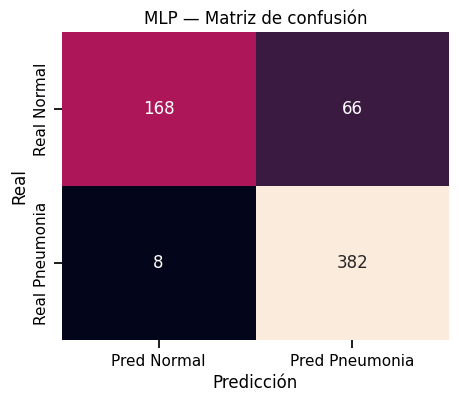

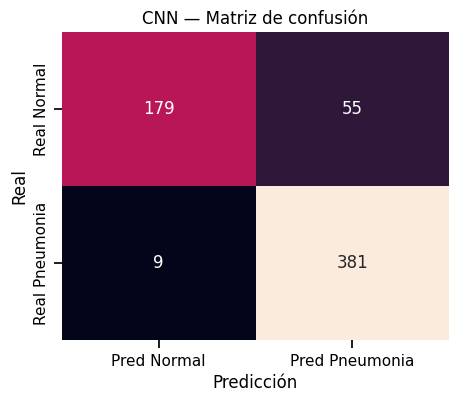

In [ ]:
# ── Matrices de confusión ───────────────────────────────────────
def plot_confusion(y_true, y_prob, threshold, title):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cbar=False,
        xticklabels=["Pred Normal", "Pred Pneumonia"],
        yticklabels=["Real Normal", "Real Pneumonia"],
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
    plt.show()

plot_confusion(y_test_true, mlp_prob, threshold=0.5, title="MLP — Matriz de confusión")
plot_confusion(y_test_true, cnn_prob, threshold=0.5, title="CNN — Matriz de confusión")

### Paso 6.4 — Curva ROC

In [ ]:
# ── Curva ROC ───────────────────────────────────────────────────
fpr_mlp, tpr_mlp, _ = roc_curve(y_test_true, mlp_prob)
fpr_cnn, tpr_cnn, _ = roc_curve(y_test_true, cnn_prob)

auc_mlp = roc_auc_score(y_test_true, mlp_prob)
auc_cnn = roc_auc_score(y_test_true, cnn_prob)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_mlp, tpr_mlp, label=f"MLP AUC={auc_mlp:.3f}")
ax.plot(fpr_cnn, tpr_cnn, label=f"CNN AUC={auc_cnn:.3f}")
ax.plot([0, 1], [0, 1], "--", color=UPCH_GRAY)
ax.set_title("Curva ROC — detección de neumonía")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate / Sensibilidad")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

### Paso 6.5 — Análisis de umbral para la CNN

Un modelo produce probabilidades, pero la etiqueta final depende del **umbral de decisión**. En problemas clínicos, este umbral no siempre debe ser 0.5.

**Pregunta guía:** si el objetivo clínico es reducir falsos negativos, ¿qué umbral recomendarías y qué costo tendría en falsos positivos?


In [ ]:
# ── Análisis de umbral ──────────────────────────────────────────
# TODO 13: prueba tres umbrales: bajo, estándar y alto.
threshold_rows = []
for th in [0.3, 0.5, 0.7]:
    threshold_rows.append(
        clinical_metrics(y_test_true, cnn_prob, threshold=th, model_name="CNN")
    )

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df[[
    "model", "threshold", "accuracy", "sensitivity_recall",
    "specificity", "precision", "f1", "FN", "FP", "TP", "TN"
]])


,model,threshold,accuracy,sensitivity_recall,specificity,precision,f1,FN,FP,TP,TN
0,CNN,0.3,0.892628,0.982051,0.743590,0.864560,0.919568,7,60,383,174
1,CNN,0.5,0.897436,0.976923,0.764957,0.873853,0.922518,9,55,381,179
2,CNN,0.7,0.899038,0.964103,0.790598,0.884706,0.922699,14,49,376,185


### Paso 6.6 — Visualización de errores

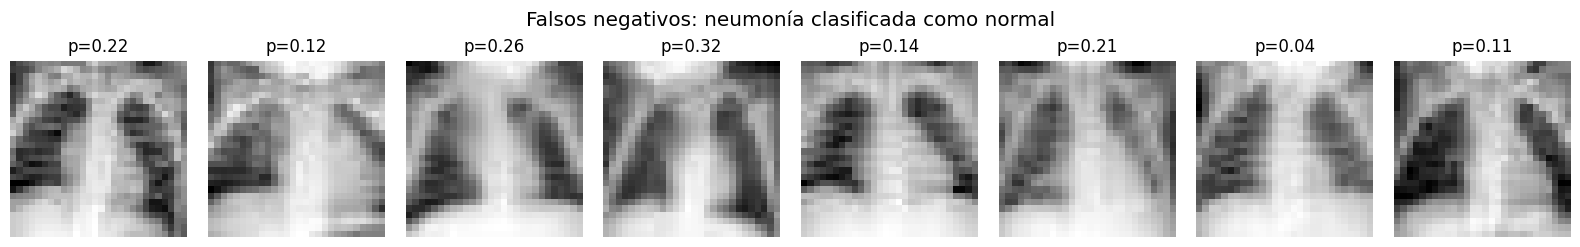

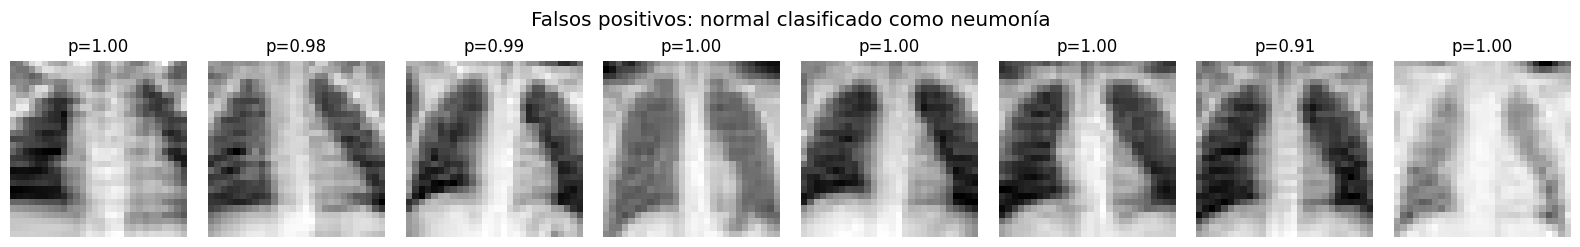

In [ ]:
# ── Visualización de falsos negativos y falsos positivos ────────
@torch.no_grad()
def collect_images_probs(model, loader, device):
    model.eval()

    images = []
    y_true = []
    y_prob = []

    for X_batch, y_batch in loader:
        logits = model(X_batch.to(device))
        probs = torch.sigmoid(logits).cpu().numpy().reshape(-1)

        images.append(X_batch.cpu())
        y_true.extend(y_batch.numpy().reshape(-1).astype(int))
        y_prob.extend(probs)

    images = torch.cat(images, dim=0)
    return images, np.array(y_true), np.array(y_prob)


def plot_errors(model, loader, device, error_type="FN", threshold=0.5, max_images=8):
    images, y_true, y_prob = collect_images_probs(model, loader, device)
    y_pred = (y_prob >= threshold).astype(int)

    if error_type == "FN":
        idxs = np.where((y_true == 1) & (y_pred == 0))[0]
        title = "Falsos negativos: neumonía clasificada como normal"
    elif error_type == "FP":
        idxs = np.where((y_true == 0) & (y_pred == 1))[0]
        title = "Falsos positivos: normal clasificado como neumonía"
    else:
        raise ValueError("error_type debe ser 'FN' o 'FP'")

    if len(idxs) == 0:
        print(f"No se encontraron errores tipo {error_type} con threshold={threshold}.")
        return

    chosen = idxs[:max_images]

    fig, axes = plt.subplots(1, len(chosen), figsize=(2 * len(chosen), 2.5))
    if len(chosen) == 1:
        axes = [axes]

    for ax, idx in zip(axes, chosen):
        ax.imshow(unnormalize_img(images[idx]), cmap="gray")
        ax.axis("off")
        ax.set_title(f"p={y_prob[idx]:.2f}")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_errors(cnn_model, test_loader, device, error_type="FN", threshold=0.5, max_images=8)
plot_errors(cnn_model, test_loader, device, error_type="FP", threshold=0.5, max_images=8)

### Paso 6.7 — Interpretación final

**📝 Tu respuesta (edita esta celda):**

> **TODO:** responde con 2–3 líneas por pregunta. Usa conceptos de CNN, MLP y métricas clínicas.

**1. ¿Qué modelo elegirías como apoyo diagnóstico: MLP o CNN? Justifica con métricas.**  
Elegiría la CNN porque presenta mejores métricas globales, especialmente ROC-AUC y F1. Estas métricas reflejan mejor la capacidad de identificar correctamente casos de neumonía.

**2. ¿Qué métrica priorizarías si quieres reducir neumonías no detectadas?**  
En casos clínicos, se debe mejorar la sensibilidad. Un valor alto implica que el modelo identifica la mayor cantidad posible de pacientes con neumonía, reduciendo los falsos negativos.

**3. ¿Qué pasa con falsos positivos y falsos negativos al bajar el umbral?**  
Al bajar el umbral, aumentan la clasificación hacia positivos. Como consecuencia se reducen los falsos negativos, pero incrementan los falsos positivos.

**4. ¿Qué umbral recomendarías para la CNN si el objetivo es reducir falsos negativos? Justifica con la tabla.**  
Recomendaría 0.3, siempre que la tabla muestre una mejora importante en sensibilidad. En un contexto clínico suele ser preferible aceptar más falsos positivos antes que perder casos reales de neumonía.

**5. ¿Por qué este modelo no debe interpretarse como reemplazo del médico?**  
Porque se pueden contener errores y se depende fuertemente de los datos de entrenamiento. La IA debe usarse como herramienta de apoyo a la decisión clínica y no como un reemplazo.


## Checklist de entrega

Antes de entregar, verifica que tu notebook incluya:

- [x] Respuestas conceptuales completas sobre MLP vs CNN, convolución, pooling y clasificación binaria.
- [x] Carga correcta de PneumoniaMNIST con splits train/validation/test.
- [x] Visualización de ejemplos de ambas clases.
- [x] Creación correcta de DataLoaders con mini-batches.
- [x] Definición funcional de `FlattenMLP`.
- [x] Definición funcional de `SimpleCNN`.
- [x] Loop explícito de PyTorch con `forward`, `loss`, `zero_grad`, `backward`, `step`.
- [x] Curvas de pérdida y accuracy para MLP y CNN.
- [x] Evaluación en test con matriz de confusión, sensibilidad, especificidad, precisión, F1 y ROC-AUC.
- [x] Análisis de umbral para la CNN.
- [x] Discusión clínica de falsos negativos y falsos positivos.
- [x] Conclusión comparando MLP vs CNN.
